# Drugi domaći

In [1]:
#Učitavanje biblioteka
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm, laplace, poisson, binom, cauchy, gamma, beta, chi2, expon
from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture as GM
import io, requests, pandas as pd

In [2]:
#Sa NASA Exoplanet Archive preuzimamo podatke za orbitalni period, 
#planetski radijus, ravnotežnu temperaturu i zvezdanu metaličnost za sve dostupne
#podatke

TAP_URL = " https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = '''
SELECT 
    pl_orbper,
    pl_rade, 
    pl_eqt, 
    st_met,
    discoverymethod
FROM pscomppars
'''

r = requests.get(TAP_URL, params={"query":query, "format": "csv"},
    timeout =120)
exo = pd.read_csv(io.StringIO(r.text))
exo.head()

,pl_orbper,pl_rade,pl_eqt,st_met,discoverymethod
0,1.003934,1.710000,1419.0,-0.05,Transit
1,8.172400,3.323214,858.0,-0.06,Transit
2,6.283855,0.800000,1108.0,0.07,Transit
3,3.173917,3.150000,1655.0,0.08,Transit
4,56.358501,4.540605,419.0,-0.20,Transit


In [3]:
#Filtiramo samo one koji imaju period manji od 10 dana 
#i prečnik veći od 8 Zemljinih prečnika jer su to uslovi
#da planeta bude vrući Jupiter

vruci_jupiter = exo[(exo["pl_orbper"] < 10) & (exo["pl_rade"] > 8)]

In [4]:
#Računamo procenat vrućih Jupitera u uzorku
procenat = len(vruci_jupiter)/len(exo) * 100
print('Udeo vrućih Jupitera u prikupljenom skupu podataka je:', np.round(procenat,2), '%')

Udeo vrućih Jupitera u prikupljenom skupu podataka je: 11.77 %


In [5]:
#ovo vraća true false vrednosti za svaku planetu, ako su ispunjena
#oba uslova onda je true
maska_vruci_jupiteri = (exo["pl_orbper"] < 10) & (exo["pl_rade"] > 8)

# ovo vraća true ako je metaličnost veća od 0.4
maska_metalicnost = exo["st_met"] > 0.4

#uzimamo samo podatke za koje je metaličnost veća od 0.4
exo_velika_metalicnost = exo[maska_metalicnost]

#Ovde prebrojavamo True vrednosti
#Imenilac broji gde su true i jedna i druga maska, 
#dakle i vrući Jupiteri i velika metaličnost 
udeo_vruci_jupiteri = (maska_vruci_jupiteri & maska_metalicnost).sum() / maska_metalicnost.sum() * 100

#Isto kao u prvom zadatku
udeo_od_svih = len(vruci_jupiter)/len(exo) * 100

print("Udeo vrućih jupitera kod zvezda velike metaličnosti:", np.round(udeo_vruci_jupiteri, 2), '%')
print("Udeo vrućih Jupitera u celom skupu podataka je:", np.round(udeo_od_svih, 2), '%')

Udeo vrućih jupitera kod zvezda velike metaličnosti: 36.36 %
Udeo vrućih Jupitera u celom skupu podataka je: 11.77 %


Vidimo da je potvrđeno da je zvezdana metaličnost bitan faktor u predviđanju formiranja džinovskih planeta.

In [6]:
#Izvlačimo podatke za metaličnost (treba nam samo to i to radi ovo .loc), 
#samo za zvezde za koje je ona veća od 0.4
#i brišemo sve ostale nan vrednosti, tj one kod kojih je uslov false
#i pretvaramo u np niz
x = exo.loc[exo["st_met"] > 0.4, "st_met"].dropna().to_numpy()
#print(x)

In [7]:
N = 10000 #Broj realizacija/koliko puta ćemo ponoviti uzorkovanje
#Prazni nizovi za upisivanje vrednosti
means = np.zeros(N)
stds = np.zeros(N)

n = len(x)

for i in range(N): #bootstrap petlja
    sample = np.random.choice(x, size=n, replace=True) #nasumično biramo n elemenata iz x
    means[i] = np.mean(sample) #srednja vrednost
    stds[i] = np.std(sample, ddof=1) #std, ddof=1 daje uzoračku standardnu devijaciju

In [8]:
x_mean = np.mean(x) #srednja vrendnost originalnog uzorka
x_std = np.std(x, ddof=1) #std originalnog uzorka

#Analitički izrazi:
se_mean = x_std / np.sqrt(n) 
se_std = x_std / np.sqrt(2*(n-1))

### Plotovanje

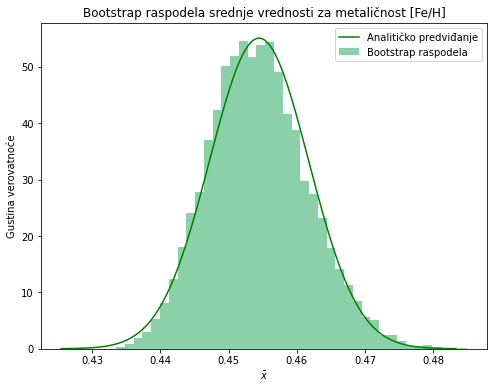

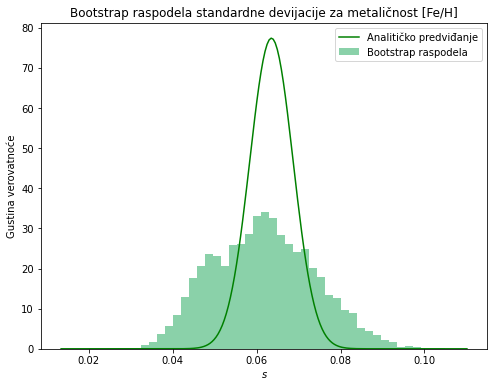

In [9]:
plt.figure(figsize=(8,6))
plt.hist(means, bins=40, density=True, alpha=0.6, color='mediumseagreen', label='Bootstrap raspodela')

mu_m = np.mean(means) #Srednja vrednost bootstrap raspodele srednjih vrednosti
sigma_m = np.std(means) #std bootstrap raspodele srednjih vrednosti

x = np.linspace(mu_m - 4*sigma_m, mu_m + 4*sigma_m, 200) #dodajemo tačke da bi teorijska raspordela bila glatka
plt.plot(x, norm.pdf(x, x_mean, se_mean), color='green', label='Analitičko predviđanje') #norm.pdf vraća gustinu verovatnoće normalne raspodele
plt.xlabel(r'$\bar{x}$')
plt.ylabel('Gustina verovatnoće')
plt.title("Bootstrap raspodela srednje vrednosti za metaličnost [Fe/H]")
plt.legend()
plt.show()


#sve isto samo za std
plt.figure(figsize=(8,6))
plt.hist(stds, bins=40, density=True, alpha=0.6, color='mediumseagreen', label='Bootstrap raspodela')

mu_s = np.mean(stds)
sigma_s = np.std(stds)

x = np.linspace(mu_s - 4*sigma_s, mu_s + 4*sigma_s, 200)
plt.plot(x, norm.pdf(x, x_std, se_std), color='green', label='Analitičko predviđanje')
plt.xlabel(r'$s$')
plt.ylabel('Gustina verovatnoće')
plt.title("Bootstrap raspodela standardne devijacije za metaličnost [Fe/H]")
plt.legend()
plt.show()

Bootstrap raspodela srednje vrednosti $\bar{x}$ metaličnosti pokazuje približno slaganje sa normalnom raspodelom, što je u skladu sa centralnom graničnom teoremom. Suprotno tome, raspodela standardne devijacije $s$ je asimetrična i odstupa od normalne raspodele zbog pozitivne definisanosti i nelinearne zavisnosti od uzorka.

Jackknife metoda bi dala prihvatljive procene za srednju vrednost, ali bi bila manje pouzdana za standardnu devijaciju, jer ne reprodukuje dobro varijabilnost nelinearnih statistika. Zbog toga je bootstrap metoda pogodnija za procenu u ovom slučaju.

3 GaussianMixture(n_components=3)


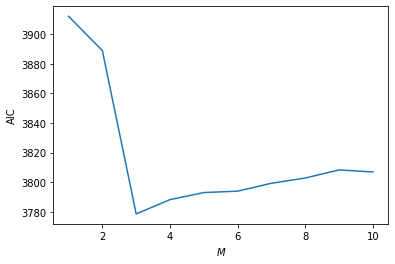

In [10]:
#Ovo nam je dato u pdf-u
rs = np.random.RandomState(seed=1)

X = np.concatenate([rs.normal(-1,1.5,350),
                    rs.normal(0, 1, 500),
                    rs.normal(3, 0.5,150)]).reshape(-1, 1)

N = np.arange(1, 11)
modeli = [None for i in range(len(N))]

for i in range(len(N)):
    modeli[i]=GM(N[i]).fit(X)

AIC = [m.aic(X) for m in modeli]
najbolje_N = N[np.argmin(AIC)]
najbolji_model = modeli[np.argmin(AIC)]
print(najbolje_N, najbolji_model)

plt.plot(N, AIC)
plt.xlabel('$M$')
plt.ylabel('AIC')
plt.show( )

### Sada hoćemo sličnu proceduru da ponovimo za raspodelu radijusa planeta $R_p$


In [11]:
#exo["pl_rade"] uzima samo radijuse planeta
#dropna() kao i gore briše nan vrednosti
#.values pretvara brednosti u np niz
#reshape(-1, 1) menja oblik niza iz redova u jednu kolonu
Rp = exo["pl_rade"].dropna().values.reshape(-1, 1)
logRp = np.log10(Rp)

In [12]:
#Ovo je sve isto kao u datom primeru samo sam promenila raspodelu

N = np.arange(1, 11)
modeli = [None for i in range(len(N))]

for i in range(len(N)):
    modeli[i] = GM(N[i]).fit(logRp)

AIC = [m.aic(logRp) for m in modeli]

najbolje_N = N[np.argmin(AIC)]
najbolji_model = modeli[np.argmin(AIC)]

print("Optimalan broj komponenti:", najbolje_N)

Optimalan broj komponenti: 10


In [13]:
#plt.figure(figsize=(8,6))
#plt.plot(N, AIC, marker='o', color='mediumseagreen')
#plt.xlabel("Broj komponenti M")
#plt.ylabel("AIC")
#plt.title(r"GMM model za $R_p$")
#plt.grid()
#plt.show()

In [14]:
#Umesto petlje i AIC-a,fitujem model sa tačno 2 komponente
najbolji_model = GM(n_components=najbolje_N, random_state=42).fit(logRp)

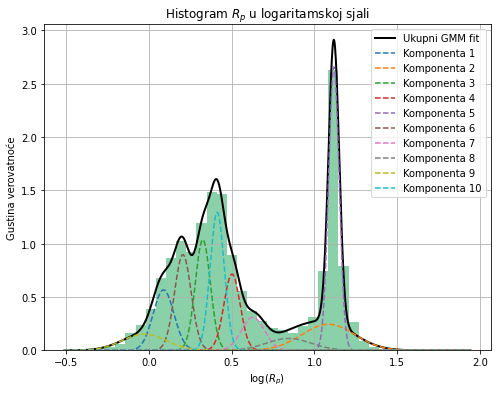

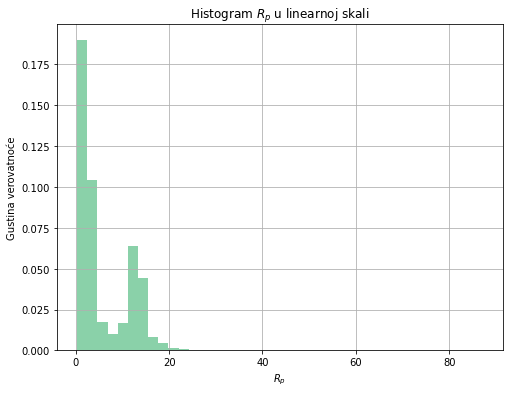

In [15]:
#pravim niz sa više tačaka da bi fit bio glađi
x = np.linspace(logRp.min(), logRp.max(), 1000).reshape(-1, 1)

#fitovanje raspodele
logprob = najbolji_model.score_samples(x)
pdf = np.exp(logprob)

#Računanje pojedinačnih komponenti unutar GMM-a
responsibilities = najbolji_model.predict_proba(x)
pdf_individual = responsibilities * pdf[:, np.newaxis]


plt.figure(figsize=(8,6))
plt.hist(logRp, bins=40, density=True, alpha=0.6, color='mediumseagreen')
#Ukupan fit
plt.plot(x, pdf, '-', lw=2, label='Ukupni GMM fit', color='black') 
#Pojedinačne komponente
for i in range(najbolje_N):
    plt.plot(x, pdf_individual[:, i], '--', lw=1.5, label=f'Komponenta {i+1}')
    
plt.title(r"Histogram $R_p$ u logaritamskoj sjali")
plt.xlabel(r'$\log (R_p)$')
plt.ylabel('Gustina verovatnoće')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,6))
plt.hist(Rp, bins=40, density=True, alpha=0.6, color='mediumseagreen')
plt.title(r"Histogram $R_p$ u linearnoj skali")
plt.xlabel(r'$R_p$')
plt.ylabel('Gustina verovatnoće')
plt.grid()
plt.show()

### Sad ponavljamo sve isto ali samo za planete koje su otkrivene metodom tranzita

In [16]:
transit = exo[exo["discoverymethod"] == "Transit"] #Izdvajam samo one koji su otkriveni metodom tranzita
Rp_t = transit["pl_rade"].dropna().values.reshape(-1, 1)
logRp_t = np.log10(Rp_t)

In [17]:
modeli_t = [None for i in range(len(N))]

for i in range(len(N)):
    modeli_t[i] = GM(N[i]).fit(logRp_t)

AIC_t = [m.aic(logRp_t) for m in modeli_t]

najbolje_N_t = N[np.argmin(AIC_t)]
najbolji_model_t = modeli_t[np.argmin(AIC_t)]

print("Optimalan broj komponenti:", najbolje_N_t)
#plt.figure(figsize=(8,6))
#plt.plot(N, AIC_t, marker='o', color='mediumseagreen')
#plt.xlabel("Broj komponenti M")
#plt.ylabel("AIC")
#plt.title(r"GMM model za $R_p$ koje su detektovane metodom tranzita")
#plt.grid()
#plt.show()

Optimalan broj komponenti: 5


In [18]:
#Umesto petlje i AIC-a,fitujem model sa tačno 2 komponente
najbolji_model_t = GM(n_components=najbolje_N_t, random_state=42).fit(logRp_t)

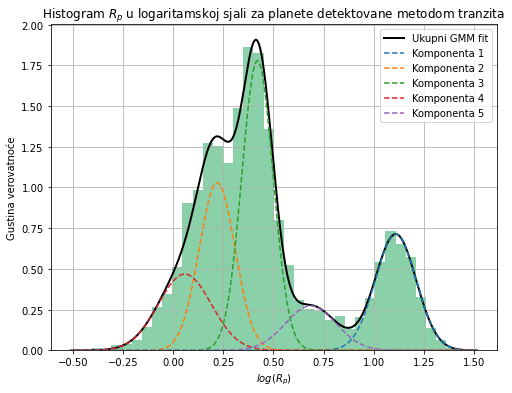

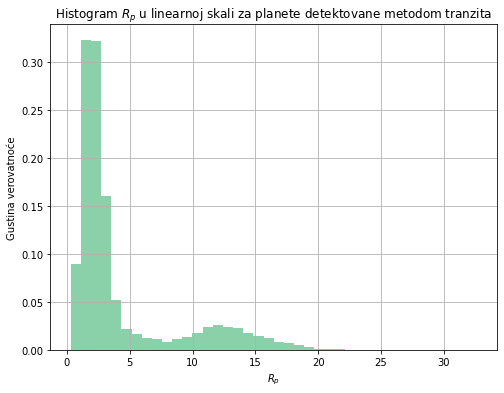

In [19]:
#pravim niz sa više tačaka da bi fit bio glađi
x_t = np.linspace(logRp_t.min(), logRp_t.max(), 1000).reshape(-1, 1)

#fitovanje raspodele
logprob_t = najbolji_model_t.score_samples(x_t)
pdf_t = np.exp(logprob_t)

#Računanje pojedinačnih komponenti unutar GMM-a
responsibilities_t = najbolji_model_t.predict_proba(x_t)
pdf_individual_t = responsibilities_t * pdf_t[:, np.newaxis]


plt.figure(figsize=(8,6))
plt.hist(logRp_t, bins=40, density=True, alpha=0.6, color='mediumseagreen')
#Ukupan fit
plt.plot(x_t, pdf_t, '-', lw=2, label='Ukupni GMM fit', color='black') 
#Pojedinačne komponente
for i in range(najbolje_N_t):
    plt.plot(x_t, pdf_individual_t[:, i], '--', lw=1.5, label=f'Komponenta {i+1}')
    
plt.title(r"Histogram $R_p$ u logaritamskoj sjali za planete detektovane metodom tranzita")
plt.xlabel(r'$log (R_p)$')
plt.ylabel('Gustina verovatnoće')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,6))
plt.hist(Rp_t, bins=40, density=True, alpha=0.6, color='mediumseagreen')
plt.title(r"Histogram $R_p$ u linearnoj skali za planete detektovane metodom tranzita")
plt.xlabel(r'$R_p$')
plt.ylabel('Gustina verovatnoće')
plt.grid()
plt.show()

Kada radijuse planeta posmatramo u logaritamskoj skali $\log_{10}(R_p)$, u obe raspodele se jasno vidi da postoje izraženi padovi (praznine). Najuočljivija je između $\log R_p = 0.5$ i $\log R_p = 1$. Ova praznina se naziva Fultonova praznina. Ona razdvaja dve populacije egzoplaneta: manje, stenovite planete (Super-Zemlje, sa radijusima ispod $1.5 R_{\oplus}$) i veće planete sa bogatim gasovitim omotačem (Sub-Neptune, sa radijusima iznad $2 R_{\oplus}$). Praznina nastaje usled procesa fotoevaporacije, gde snažno zračenje matične zvezde "razduvava" atmosferu planeta koje su preblizu, pretvarajući ih iz sub-Neptuna u ogoljene.

<hr style="height: 3px;">

### Sad treba da pronađemo planetu čije je $T_{eq}$ najbliže Zemljinoj

In [20]:
exo2 = exo.dropna(subset=["pl_eqt"]) #Uzimamo sve za koje su određeni Teq

T_eq_z = 255 #K Ovo je poznat podatak

idx = (exo2["pl_eqt"] - T_eq_z).abs().idxmin() #Tražimo gde je aapsolutna razlika između Teq i Teq Zemlje najmanja, odnosno index tog sistema
planeta = exo2.loc[idx] #Ovo izvuče samo sistem sa traženim indeksom, kao i gore kad sam koristila loc

In [21]:
Teq = planeta["pl_eqt"] #Uzimam njenu Teq da bih u bazi našla baš taj sistem i izvukla ostale podatke koji mi se traže, u principu mogu bilo koji drugi parametar da uzmem

query = f"""
SELECT
    pl_name,
    hostname,
    sy_pnum,
    sy_snum,
    pl_bmasse,
    pl_orbeccen,
    discoverymethod,
    pl_eqt,
    disc_telescope
FROM pscomppars
WHERE pl_eqt = '{Teq}'
"""

r = requests.get(TAP_URL, params={"query":query, "format": "csv"},
    timeout =120)
planeta_podaci = pd.read_csv(io.StringIO(r.text))
planeta_podaci.head()

,pl_name,hostname,sy_pnum,sy_snum,pl_bmasse,pl_orbeccen,discoverymethod,pl_eqt,disc_telescope
0,HD 40307 g,HD 40307,5,1,7.1,0.29,Radial Velocity,255.0,3.6 m ESO Telescope


In [22]:
print('Broj zvezda je:', planeta_podaci["sy_snum"].values)
print('Broj planeta je:', planeta_podaci["sy_pnum"].values)
print('Metoda otkrića je:', planeta_podaci["discoverymethod"].values)
print('Masa planete je:', planeta_podaci["pl_bmasse"].values)
print('Ekscentricitet je:', planeta_podaci["pl_orbeccen"].values)
print('Teleskop kojim je snimano je:', planeta_podaci["disc_telescope"].values)

Broj zvezda je: [1]
Broj planeta je: [5]
Metoda otkrića je: ['Radial Velocity']
Masa planete je: [7.1]
Ekscentricitet je: [0.29]
Teleskop kojim je snimano je: ['3.6 m ESO Telescope']


### Sad treba konstruisati empirijsku kumulativnu raspodelu

In [23]:
teq = exo["pl_eqt"].dropna().values #Sve kao gore :)
teq_sorted = np.sort(teq) #Soritram vrendosti Teq jer ECDF mora da bude monotono rastuća fja

ecdf = np.arange(1, len(teq_sorted)+1) / len(teq_sorted)
#Pravim niz od jedan do N+1 i delim sa N da bi bilo u intervalu od 0 do 1
#ECDF pokazuje koliki deo podataka je manji ili jednak od određene vrednosti

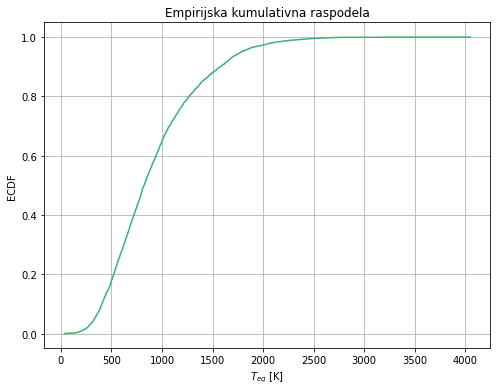

In [24]:
plt.figure(figsize=(8,6))
plt.plot(teq_sorted, ecdf, color='mediumseagreen')
plt.xlabel(r"$T_{eq}$ [K]")
plt.ylabel("ECDF")
plt.title("Empirijska kumulativna raspodela")
plt.grid()
plt.show()

### Metoda inverznog uzorkovanja

In [25]:
#Generišem N_syn uzoraka iz uniformne raspodele
Nsyn = 1000
u = np.random.uniform(0, 1, Nsyn)
sinteticki_Teq = np.interp(u, ecdf, teq_sorted) #inverzna interpolacija, uzme uniformnu verovatnoću i pronađe koja temperatura joj odgovara

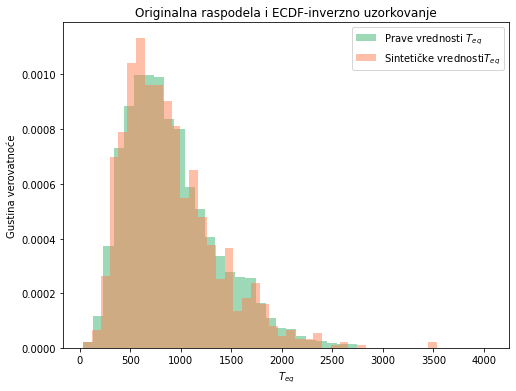

In [26]:
plt.figure(figsize=(8,6))
plt.hist(teq, bins=40, density=True, alpha=0.5, label=r"Prave vrednosti $T_{eq}$", color='mediumseagreen')
plt.hist(sinteticki_Teq, bins=40, density=True, alpha=0.5, label=r"Sintetičke vrednosti$T_{eq}$", color='coral')
plt.title("Originalna raspodela i ECDF-inverzno uzorkovanje")
plt.xlabel(r'$T_{eq}$')
plt.ylabel('Gustina verovatnoće')
plt.legend()
plt.show()

ECDF inverzno uzorkovanje se razlikuje od bootstrap metode, iako obe metode koriste empirijske podatke kao polaznu tačku.

Bootstrap metoda generiše nove uzorke tako što resampluje originalne podatke sa vraćanjem. Time se očuvaju diskretne vrednosti i struktura originalnog uzorka, a cilj je procena nesigurnosti statistika (npr. srednje vrednosti, varijanse). Bootstrap ne pokušava da modeluje kontinuiranu raspodelu, već aproksimira distribuciju statistike koja bi se dobila ponovljenim posmatranjem istog procesa.

Nasuprot tome, ECDF inverzno uzorkovanje konstruiše kontinuiranu empirijsku raspodelu i zatim iz nje generiše nove vrednosti. Iako je zasnovano na podacima, ono efektivno čini glađom diskretnu prirodu uzorka i omogućava generisanje novih sintetičkih podataka koji nisu ograničeni na originalne vrednosti. ECDF uzorkovanje je metoda generisanja podataka iz empirijske raspodele, dok je bootstrap metoda za procenu nesigurnosti statistika.

### Pitanje koju bismo raspodelu izabrali za fitovanje $T_{eq}$

Raspodela ravnotežnih temperatura $T_{eq}$ laneta nije simetrična i ne može dobro da se opiše normalnom raspodelom. Sa gornjeg grafika se vidi asimetrija i dugi rep ka desnoj strani odnosno ka visokim temperaturama.

Zbog toga su možda dobri izbori:

1. Log-normalna raspodela

Ako se uzme u obzir da je: $T_{eq}$ rezultat množenja više fizičkih faktora (luminozitet zvezde, velika poluosa, albedo), onda log-transformacija često vodi ka približno normalnoj raspodeli.

Zbog toga log-normalni model daje dobar opis: podržava samo pozitivne vrednosti i prirodno daje asimetričan oblik i dobro bi modelovao rep ka visokim temperaturama

2. Gama raspodela

Gama raspodela je takođe pogodna jer ona definiše samo pozitivne vrednosti i dobro modeluje asimetriju.
